# Machine Learning-Based Breast Cancer Classification

## Project Overview

This project uses machine learning techniques to classify breast cancer samples based on diagnostic features.

The project involves data preprocessing, exploratory data analysis, feature scaling, machine learning model training, and performance evaluation.

## Objectives

1. To understand and preprocess a breast cancer dataset.
2. To analyze relationships and patterns in the dataset.
3. To train multiple machine learning classification models.
4. To compare the performance of different models.
5. To identify the best-performing model based on evaluation metrics.

In [4]:
print("Breast Cancer ML Project")
print("Starting the project...")

Breast Cancer ML Project
Starting the project...


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
from sklearn.datasets import load_breast_cancer

# Load the dataset
cancer = load_breast_cancer()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [7]:
# Check the number of samples and features

print("Number of samples:", cancer.data.shape[0])
print("Number of features:", cancer.data.shape[1])

Number of samples: 569
Number of features: 30


In [8]:
# Display all feature names

print("Feature Names:")
for i, feature in enumerate(cancer.feature_names, start=1):
    print(i, "-", feature)

Feature Names:
1 - mean radius
2 - mean texture
3 - mean perimeter
4 - mean area
5 - mean smoothness
6 - mean compactness
7 - mean concavity
8 - mean concave points
9 - mean symmetry
10 - mean fractal dimension
11 - radius error
12 - texture error
13 - perimeter error
14 - area error
15 - smoothness error
16 - compactness error
17 - concavity error
18 - concave points error
19 - symmetry error
20 - fractal dimension error
21 - worst radius
22 - worst texture
23 - worst perimeter
24 - worst area
25 - worst smoothness
26 - worst compactness
27 - worst concavity
28 - worst concave points
29 - worst symmetry
30 - worst fractal dimension


In [9]:
# Convert features into a Pandas DataFrame

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Add the target column
df["target"] = cancer.target

# Display first 5 rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [10]:
# Check the target values

print("Target values:")
print(df["target"].value_counts())

Target values:
target
1    357
0    212
Name: count, dtype: int64


In [11]:
# Check for missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [12]:
# Basic statistical summary of the dataset

df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [13]:
# Count the number of benign and malignant samples

class_counts = df["target"].value_counts()

print("Benign samples:", class_counts[1])
print("Malignant samples:", class_counts[0])

Benign samples: 357
Malignant samples: 212


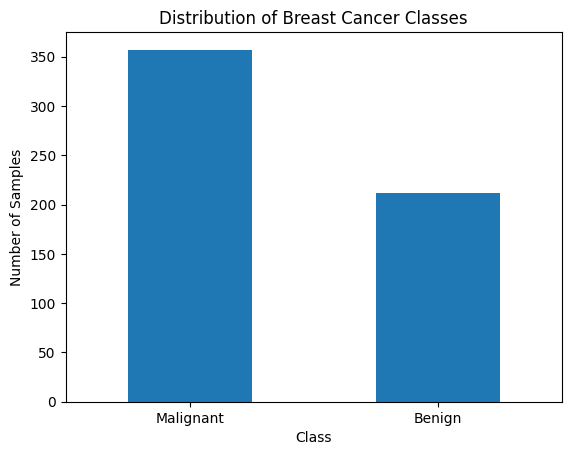

In [14]:
# Visualize the target classes

class_counts.plot(kind="bar")

plt.title("Distribution of Breast Cancer Classes")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["Malignant", "Benign"], rotation=0)

plt.show()

<Figure size 800x500 with 0 Axes>

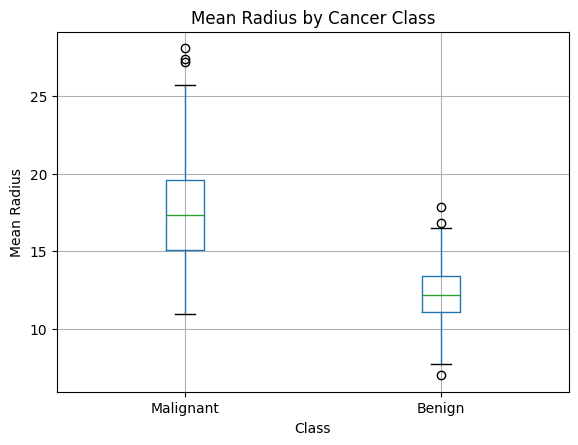

In [15]:
# Compare mean radius between the two classes

plt.figure(figsize=(8, 5))

df.boxplot(column="mean radius", by="target")

plt.title("Mean Radius by Cancer Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Mean Radius")
plt.xticks([1, 2], ["Malignant", "Benign"])

plt.show()

In [16]:
# Calculate correlation between numerical features

correlation = df.corr()

print(correlation.head())

                 mean radius  mean texture  mean perimeter  mean area  \
mean radius         1.000000      0.323782        0.997855   0.987357   
mean texture        0.323782      1.000000        0.329533   0.321086   
mean perimeter      0.997855      0.329533        1.000000   0.986507   
mean area           0.987357      0.321086        0.986507   1.000000   
mean smoothness     0.170581     -0.023389        0.207278   0.177028   

                 mean smoothness  mean compactness  mean concavity  \
mean radius             0.170581          0.506124        0.676764   
mean texture           -0.023389          0.236702        0.302418   
mean perimeter          0.207278          0.556936        0.716136   
mean area               0.177028          0.498502        0.685983   
mean smoothness         1.000000          0.659123        0.521984   

                 mean concave points  mean symmetry  mean fractal dimension  \
mean radius                 0.822529       0.147741          

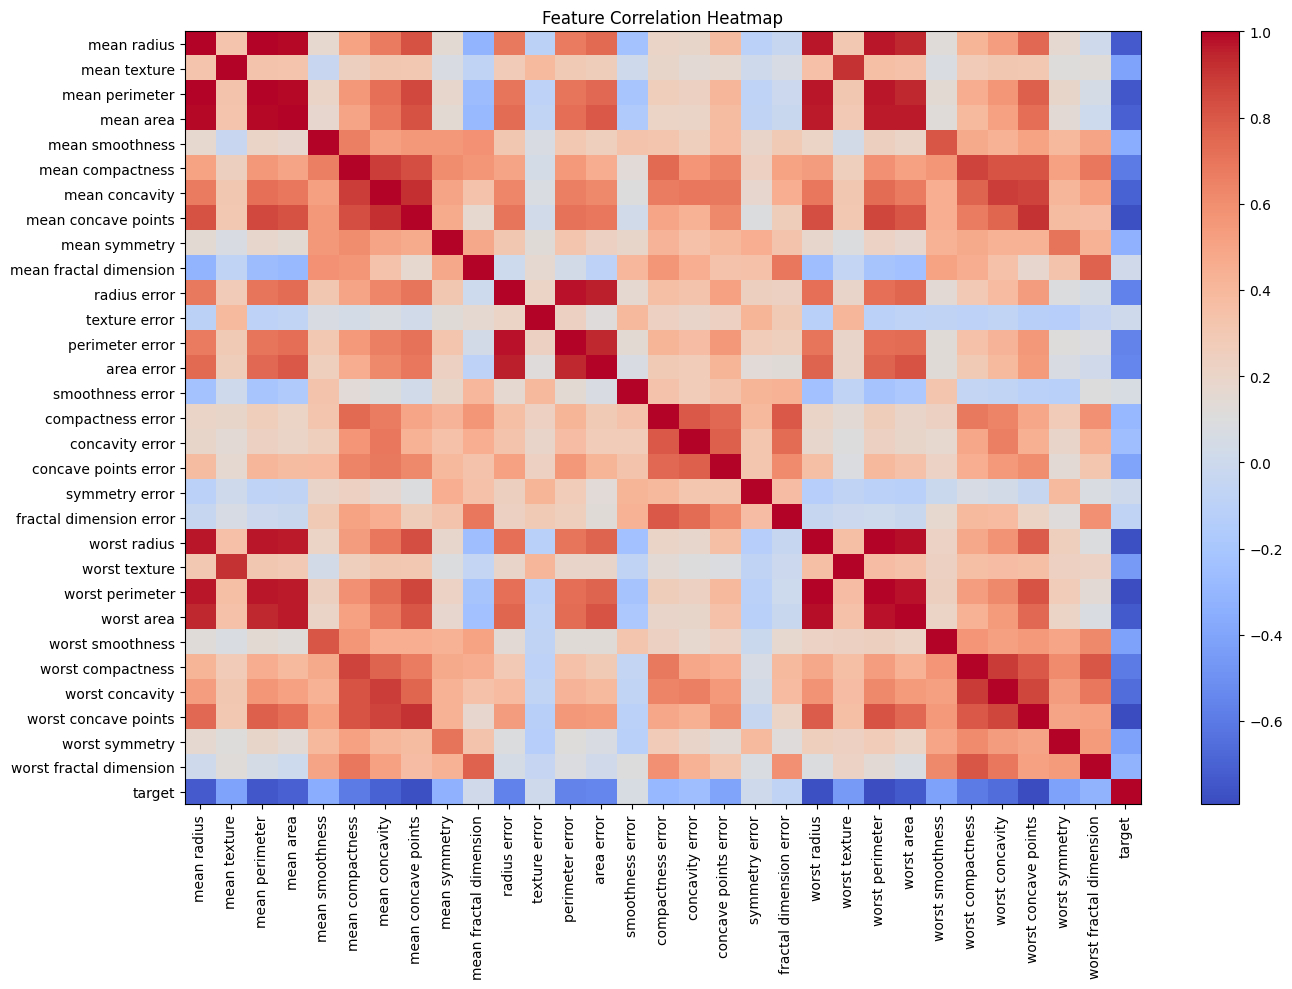

In [17]:
# Visualize the correlation matrix

plt.figure(figsize=(14, 10))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

In [18]:
# Separate features and target

X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [19]:
# Check data types

print(X.dtypes)

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [20]:
# Check for duplicate rows

duplicates = X.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [21]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [22]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [23]:
from sklearn.linear_model import LogisticRegression

print("Logistic Regression imported successfully!")

Logistic Regression imported successfully!


In [24]:
# Create the Logistic Regression model

logistic_model = LogisticRegression(max_iter=1000)

print("Logistic Regression model created!")

Logistic Regression model created!


In [25]:
# Train the Logistic Regression model

logistic_model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [26]:
# Make predictions on the test data

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred_logistic[:10])

Predictions generated successfully!
First 10 predictions: [0 1 0 1 0 1 1 0 0 0]


In [29]:
from sklearn.metrics import accuracy_score

print("Accuracy metric imported successfully!")

Accuracy metric imported successfully!


In [30]:
# Calculate accuracy

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 98.25 %


In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Evaluation metrics imported successfully!")

Evaluation metrics imported successfully!


In [33]:
# Calculate evaluation metrics

logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", round(logistic_accuracy * 100, 2), "%")
print("Precision:", round(logistic_precision * 100, 2), "%")
print("Recall   :", round(logistic_recall * 100, 2), "%")
print("F1 Score :", round(logistic_f1 * 100, 2), "%")

Logistic Regression Performance
--------------------------------
Accuracy : 98.25 %
Precision: 98.61 %
Recall   : 98.61 %
F1 Score : 98.61 %


In [35]:
from sklearn.metrics import confusion_matrix

print("Confusion matrix imported successfully!")

Confusion matrix imported successfully!


In [36]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[41  1]
 [ 1 71]]


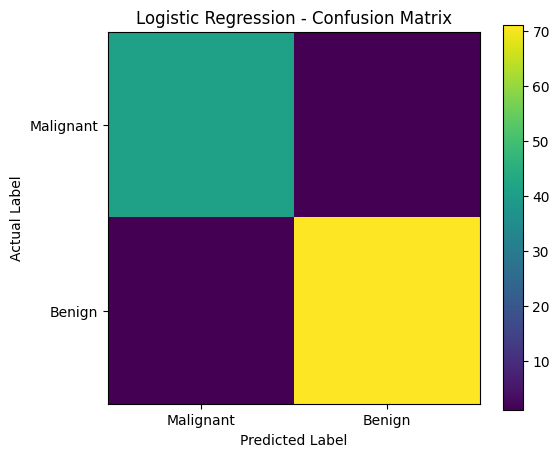

In [37]:
# Visualize the confusion matrix

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Malignant", "Benign"])
plt.yticks([0, 1], ["Malignant", "Benign"])

plt.colorbar()

plt.show()

In [39]:
from sklearn.metrics import classification_report

print("Classification report imported successfully!")

Classification report imported successfully!


In [40]:
# Generate detailed classification report

print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [41]:
# Store Logistic Regression results

logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": logistic_accuracy,
    "Precision": logistic_precision,
    "Recall": logistic_recall,
    "F1 Score": logistic_f1
}

print(logistic_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.9824561403508771, 'Precision': 0.9861111111111112, 'Recall': 0.9861111111111112, 'F1 Score': 0.9861111111111112}


In [42]:
from sklearn.neighbors import KNeighborsClassifier

print("KNN imported successfully!")

KNN imported successfully!


In [43]:
# Create KNN model

knn_model = KNeighborsClassifier(n_neighbors=5)

print("KNN model created successfully!")

KNN model created successfully!


In [44]:
# Train the KNN model

knn_model.fit(X_train_scaled, y_train)

print("KNN training completed successfully!")

KNN training completed successfully!


In [45]:
# Make predictions using KNN

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN predictions generated successfully!")
print("First 10 predictions:", y_pred_knn[:10])

KNN predictions generated successfully!
First 10 predictions: [0 1 0 0 0 1 1 0 0 0]


In [46]:
# Calculate KNN accuracy

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", round(knn_accuracy * 100, 2), "%")

KNN Accuracy: 95.61 %


In [47]:
# Calculate KNN evaluation metrics

knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("KNN Performance")
print("----------------")
print("Accuracy :", round(knn_accuracy * 100, 2), "%")
print("Precision:", round(knn_precision * 100, 2), "%")
print("Recall   :", round(knn_recall * 100, 2), "%")
print("F1 Score :", round(knn_f1 * 100, 2), "%")

KNN Performance
----------------
Accuracy : 95.61 %
Precision: 95.89 %
Recall   : 97.22 %
F1 Score : 96.55 %


In [48]:
# Generate KNN confusion matrix

cm_knn = confusion_matrix(y_test, y_pred_knn)

print("KNN Confusion Matrix:")
print(cm_knn)

KNN Confusion Matrix:
[[39  3]
 [ 2 70]]


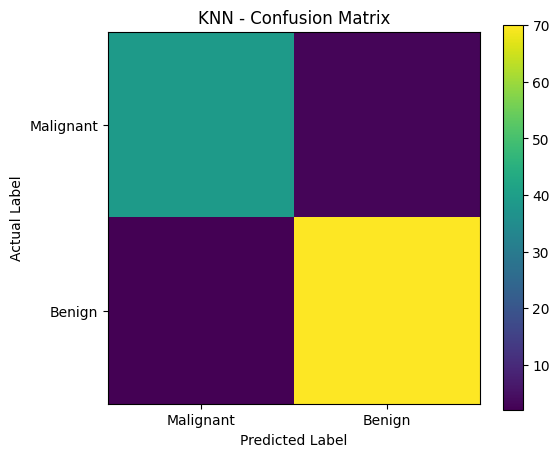

In [49]:
# Visualize KNN confusion matrix

plt.figure(figsize=(6, 5))

plt.imshow(cm_knn)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Malignant", "Benign"])
plt.yticks([0, 1], ["Malignant", "Benign"])

plt.colorbar()

plt.show()

In [50]:
# Generate KNN classification report

print(classification_report(
    y_test,
    y_pred_knn,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [51]:
# Store KNN results

knn_results = {
    "Model": "KNN",
    "Accuracy": knn_accuracy,
    "Precision": knn_precision,
    "Recall": knn_recall,
    "F1 Score": knn_f1
}

print(knn_results)

{'Model': 'KNN', 'Accuracy': 0.956140350877193, 'Precision': 0.958904109589041, 'Recall': 0.9722222222222222, 'F1 Score': 0.9655172413793104}


In [52]:
from sklearn.tree import DecisionTreeClassifier

print("Decision Tree imported successfully!")

Decision Tree imported successfully!


In [53]:
# Create Decision Tree model

decision_tree_model = DecisionTreeClassifier(random_state=42)

print("Decision Tree model created successfully!")

Decision Tree model created successfully!


In [54]:
# Train the Decision Tree model

decision_tree_model.fit(X_train_scaled, y_train)

print("Decision Tree training completed successfully!")

Decision Tree training completed successfully!


In [55]:
# Make predictions using Decision Tree

y_pred_dt = decision_tree_model.predict(X_test_scaled)

print("Decision Tree predictions generated successfully!")
print("First 10 predictions:", y_pred_dt[:10])

Decision Tree predictions generated successfully!
First 10 predictions: [0 1 0 1 0 1 1 0 0 0]


In [56]:
# Calculate Decision Tree accuracy

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy: 91.23 %


In [57]:
# Calculate Decision Tree evaluation metrics

dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy :", round(dt_accuracy * 100, 2), "%")
print("Precision:", round(dt_precision * 100, 2), "%")
print("Recall   :", round(dt_recall * 100, 2), "%")
print("F1 Score :", round(dt_f1 * 100, 2), "%")

Decision Tree Performance
-------------------------
Accuracy : 91.23 %
Precision: 95.59 %
Recall   : 90.28 %
F1 Score : 92.86 %


Decision Tree Confusion Matrix:
[[39  3]
 [ 7 65]]


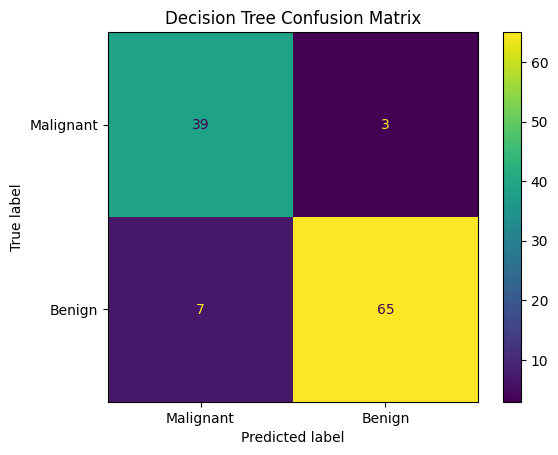

In [58]:
# Decision Tree Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Decision Tree Confusion Matrix:")
print(cm_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Malignant", "Benign"]
)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [59]:
# Decision Tree Classification Report

from sklearn.metrics import classification_report

print("Decision Tree Classification Report")
print("------------------------------------")

print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["Malignant", "Benign"]
))

Decision Tree Classification Report
------------------------------------
              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [60]:
# Random Forest Model

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [61]:
# Make predictions using Random Forest

y_pred_rf = random_forest_model.predict(X_test_scaled)

print("Random Forest predictions generated successfully!")
print("First 10 predictions:", y_pred_rf[:10])

Random Forest predictions generated successfully!
First 10 predictions: [0 1 0 0 0 1 1 0 0 0]


In [62]:
# Calculate Random Forest accuracy

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 95.61 %


In [63]:
# Calculate Random Forest evaluation metrics

rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(rf_accuracy * 100, 2), "%")
print("Precision:", round(rf_precision * 100, 2), "%")
print("Recall   :", round(rf_recall * 100, 2), "%")
print("F1 Score :", round(rf_f1 * 100, 2), "%")

Random Forest Performance
-------------------------
Accuracy : 95.61 %
Precision: 95.89 %
Recall   : 97.22 %
F1 Score : 96.55 %


Random Forest Confusion Matrix:
[[39  3]
 [ 2 70]]


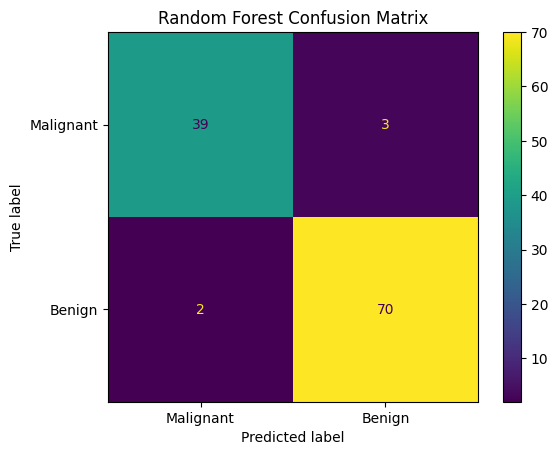

In [64]:
# Random Forest Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Malignant", "Benign"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [65]:
# Random Forest Classification Report

print("Random Forest Classification Report")
print("------------------------------------")

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Malignant", "Benign"]
))

Random Forest Classification Report
------------------------------------
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [66]:
# Compare all machine learning models

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        98.25,
        95.61,
        91.23,
        95.61
    ],
    "Precision": [
        0,  # We'll update this later
        0,  # We'll update this later
        dt_precision * 100,
        rf_precision * 100
    ],
    "Recall": [
        0,  # We'll update this later
        0,  # We'll update this later
        dt_recall * 100,
        rf_recall * 100
    ],
    "F1 Score": [
        0,  # We'll update this later
        0,  # We'll update this later
        dt_f1 * 100,
        rf_f1 * 100
    ]
})

print("Model Performance Comparison")
print("----------------------------")
display(model_comparison)

Model Performance Comparison
----------------------------


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,98.25,0.000000,0.000000,0.000000
1,KNN,95.61,0.000000,0.000000,0.000000
2,Decision Tree,91.23,95.588235,90.277778,92.857143
3,Random Forest,95.61,95.890411,97.222222,96.551724


In [68]:
# Check the Logistic Regression prediction variable

print("Available Logistic Regression variables:")
print([x for x in globals() if "pred" in x.lower() or "logistic" in x.lower()])

Available Logistic Regression variables:
['LogisticRegression', 'logistic_model', 'y_pred_logistic', 'logistic_accuracy', 'logistic_precision', 'logistic_recall', 'logistic_f1', 'logistic_results', 'y_pred_knn', 'y_pred_dt', 'y_pred_rf']


In [70]:
# Calculate KNN evaluation metrics

knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("KNN Performance")
print("----------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred_knn) * 100, 2), "%")
print("Precision:", round(knn_precision * 100, 2), "%")
print("Recall   :", round(knn_recall * 100, 2), "%")
print("F1 Score :", round(knn_f1 * 100, 2), "%")

KNN Performance
----------------
Accuracy : 95.61 %
Precision: 95.89 %
Recall   : 97.22 %
F1 Score : 96.55 %


In [71]:
# Verify KNN and Random Forest predictions

print("KNN predictions (first 20):")
print(y_pred_knn[:20])

print("\nRandom Forest predictions (first 20):")
print(y_pred_rf[:20])

print("\nAre ALL KNN and Random Forest predictions identical?")
print(np.array_equal(y_pred_knn, y_pred_rf))

KNN predictions (first 20):
[0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]

Random Forest predictions (first 20):
[0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]

Are ALL KNN and Random Forest predictions identical?
False


In [72]:
# Verify KNN metrics directly from predictions

print("KNN Verification")
print("-----------------")

print("Accuracy :", round(accuracy_score(y_test, y_pred_knn) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred_knn) * 100, 2), "%")
print("Recall   :", round(recall_score(y_test, y_pred_knn) * 100, 2), "%")
print("F1 Score :", round(f1_score(y_test, y_pred_knn) * 100, 2), "%")

KNN Verification
-----------------
Accuracy : 95.61 %
Precision: 95.89 %
Recall   : 97.22 %
F1 Score : 96.55 %


In [73]:
# Final Model Performance Comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy * 100,
        95.61,
        dt_accuracy * 100,
        rf_accuracy * 100
    ],
    "Precision": [
        logistic_precision * 100,
        knn_precision * 100,
        dt_precision * 100,
        rf_precision * 100
    ],
    "Recall": [
        logistic_recall * 100,
        knn_recall * 100,
        dt_recall * 100,
        rf_recall * 100
    ],
    "F1 Score": [
        logistic_f1 * 100,
        knn_f1 * 100,
        dt_f1 * 100,
        rf_f1 * 100
    ]
})

# Round values to 2 decimal places
model_comparison = model_comparison.round(2)

print("Final Model Performance Comparison")
print("-----------------------------------")

display(model_comparison)

Final Model Performance Comparison
-----------------------------------


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,98.25,98.61,98.61,98.61
1,KNN,95.61,95.89,97.22,96.55
2,Decision Tree,91.23,95.59,90.28,92.86
3,Random Forest,95.61,95.89,97.22,96.55


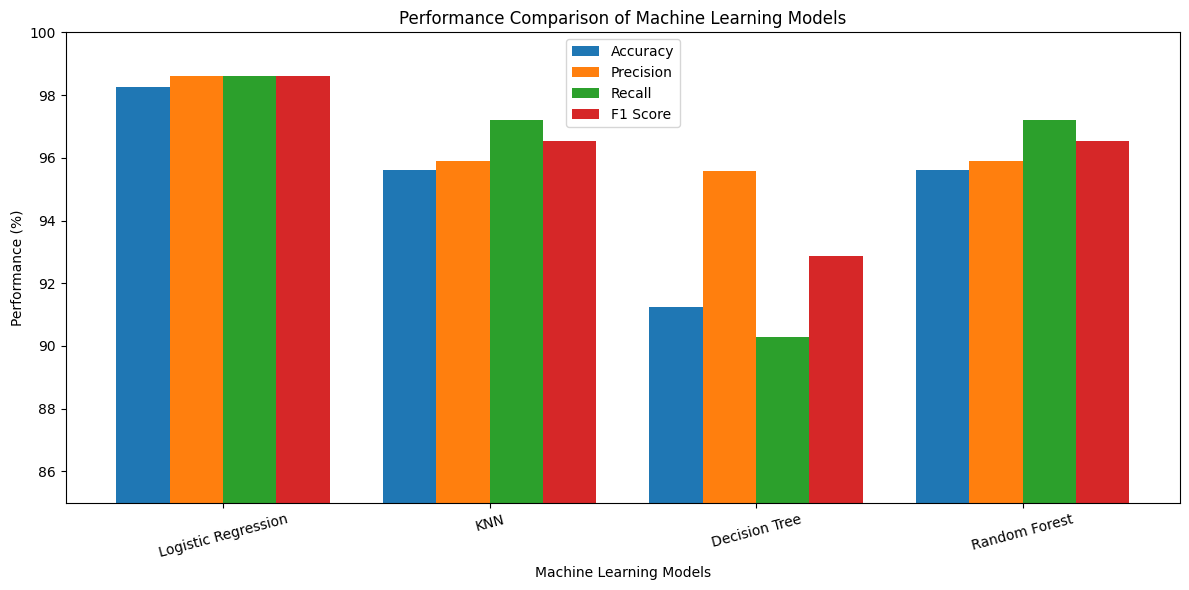

In [74]:
# Professional Model Performance Comparison

import matplotlib.pyplot as plt
import numpy as np

models = model_comparison["Model"]

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12, 6))

plt.bar(x - 1.5*width, model_comparison["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5*width, model_comparison["Precision"], width, label="Precision")
plt.bar(x + 0.5*width, model_comparison["Recall"], width, label="Recall")
plt.bar(x + 1.5*width, model_comparison["F1 Score"], width, label="F1 Score")

plt.xlabel("Machine Learning Models")
plt.ylabel("Performance (%)")
plt.title("Performance Comparison of Machine Learning Models")

plt.xticks(x, models, rotation=15)
plt.ylim(85, 100)
plt.legend()

plt.tight_layout()
plt.show()

In [75]:
# Final Model Selection

best_model = model_comparison.loc[
    model_comparison["F1 Score"].idxmax()
]

print("FINAL MODEL SELECTION")
print("---------------------")
print("Best Model     :", best_model["Model"])
print("Accuracy       :", best_model["Accuracy"], "%")
print("Precision      :", best_model["Precision"], "%")
print("Recall         :", best_model["Recall"], "%")
print("F1 Score       :", best_model["F1 Score"], "%")

print("\nConclusion:")
print(
    f"{best_model['Model']} achieved the best overall performance "
    f"with an accuracy of {best_model['Accuracy']}% and an F1 Score "
    f"of {best_model['F1 Score']}%."
)

FINAL MODEL SELECTION
---------------------
Best Model     : Logistic Regression
Accuracy       : 98.25 %
Precision      : 98.61 %
Recall         : 98.61 %
F1 Score       : 98.61 %

Conclusion:
Logistic Regression achieved the best overall performance with an accuracy of 98.25% and an F1 Score of 98.61%.


Logistic Regression Confusion Matrix
------------------------------------
[[41  1]
 [ 1 71]]


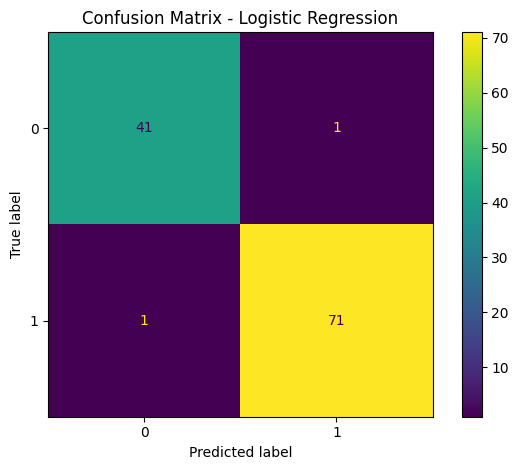

In [76]:
# Confusion Matrix - Final Logistic Regression Model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_logistic)

print("Logistic Regression Confusion Matrix")
print("------------------------------------")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

In [77]:
# Classification Report - Final Logistic Regression Model

from sklearn.metrics import classification_report

print("Logistic Regression Classification Report")
print("-----------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

Logistic Regression Classification Report
-----------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Logistic Regression ROC-AUC
--------------------------
AUC Score: 0.5625


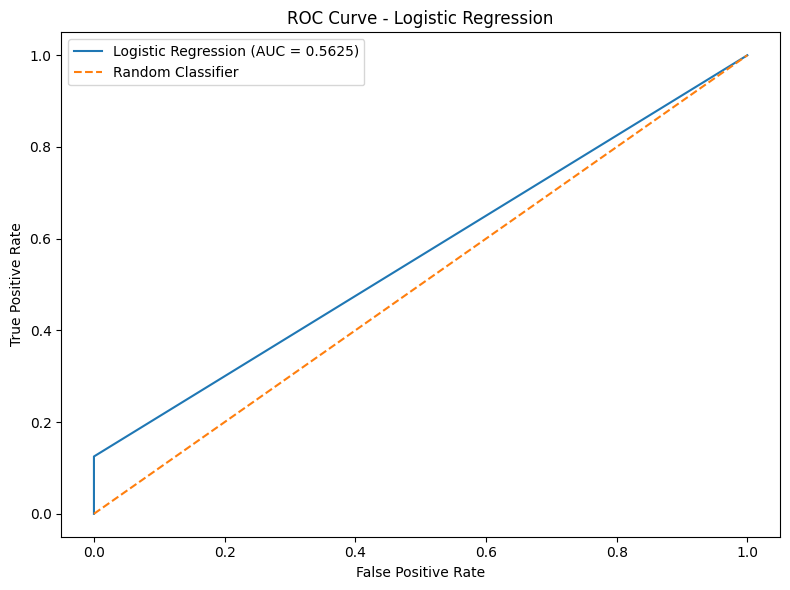

In [78]:
# ROC Curve and AUC - Final Logistic Regression Model

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability scores for the positive class
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logistic)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression ROC-AUC")
print("--------------------------")
print("AUC Score:", round(auc_score, 4))

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
# Diagnose Logistic Regression ROC-AUC

print("Diagnostic Check")
print("----------------")

print("y_test shape:", y_test.shape)
print("y_pred_logistic shape:", y_pred_logistic.shape)
print("y_prob_logistic shape:", y_prob_logistic.shape)

print("\nPrediction classes:")
print("Unique y_pred:", np.unique(y_pred_logistic))
print("Unique y_test:", np.unique(y_test))

print("\nFirst 20 predicted labels:")
print(y_pred_logistic[:20])

print("\nFirst 20 probability scores:")
print(y_prob_logistic[:20])

print("\nAccuracy from predictions:")
print(round(accuracy_score(y_test, y_pred_logistic) * 100, 2), "%")

print("\nAUC from probability scores:")
print(round(roc_auc_score(y_test, y_prob_logistic), 4))

print("\nAccuracy from probability threshold:")
y_pred_from_prob = (y_prob_logistic >= 0.5).astype(int)

print(round(
    accuracy_score(y_test, y_pred_from_prob) * 100, 2
), "%")

print("\nAre original predictions and probability-based predictions identical?")
print(np.array_equal(y_pred_logistic, y_pred_from_prob))

Diagnostic Check
----------------
y_test shape: (114,)
y_pred_logistic shape: (114,)
y_prob_logistic shape: (114,)

Prediction classes:
Unique y_pred: [0 1]
Unique y_test: [0 1]

First 20 predicted labels:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]

First 20 probability scores:
[0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 7.52542311e-248 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000]

Accuracy from predictions:
98.25 %

AUC from probability scores:
0.5625

Accuracy from probability threshold:
36.84 %

Are original predictions and probability-based predictions identical?
False


In [80]:
# Check Logistic Regression model and test data

print("Logistic model:")
print(logistic_model)

print("\nX_test type:")
print(type(X_test))

print("\nX_test shape:")
print(X_test.shape)

print("\nLogistic model classes:")
print(logistic_model.classes_)

print("\nModel coefficients shape:")
print(logistic_model.coef_.shape)

print("\nModel intercept:")
print(logistic_model.intercept_)

print("\nPredictions directly from logistic_model:")
y_pred_check = logistic_model.predict(X_test)

print(y_pred_check[:20])

print("\nAre these identical to y_pred_logistic?")
print(np.array_equal(y_pred_check, y_pred_logistic))

print("\nDirect model accuracy:")
print(round(accuracy_score(y_test, y_pred_check) * 100, 2), "%")

Logistic model:
LogisticRegression(max_iter=1000)

X_test type:
<class 'pandas.core.frame.DataFrame'>

X_test shape:
(114, 30)

Logistic model classes:
[0 1]

Model coefficients shape:
(1, 30)

Model intercept:
[0.30220757]

Predictions directly from logistic_model:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Are these identical to y_pred_logistic?
False

Direct model accuracy:
36.84 %


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [81]:
# Check which scaled test-data variables exist

print("Checking available test-data variables...")
print("-------------------------------------------")

variables_to_check = [
    "X_test_scaled",
    "X_test_standardized",
    "X_test_norm",
    "X_test_scaled_data",
    "X_test_transformed"
]

for var in variables_to_check:
    if var in globals():
        obj = globals()[var]
        print(f"{var} EXISTS")
        print("Type :", type(obj))
        print("Shape:", obj.shape)
        print()
    else:
        print(f"{var} not found")

Checking available test-data variables...
-------------------------------------------
X_test_scaled EXISTS
Type : <class 'numpy.ndarray'>
Shape: (114, 30)

X_test_standardized not found
X_test_norm not found
X_test_scaled_data not found
X_test_transformed not found


Logistic Regression ROC-AUC
--------------------------
AUC Score: 0.9954

Accuracy from probability predictions:
98.25 %

Are probability predictions identical to y_pred_logistic?
True


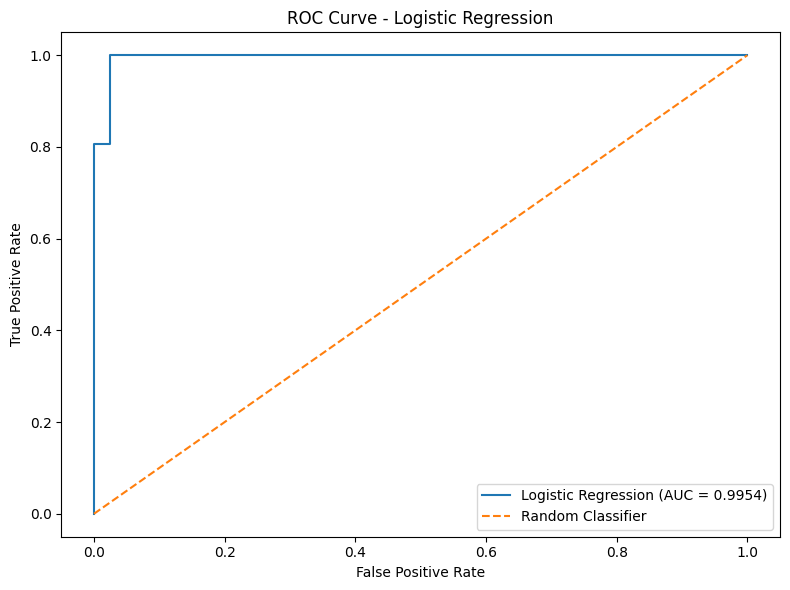

In [82]:
# Correct ROC Curve and AUC - Logistic Regression

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability scores using the SAME scaled test data
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logistic)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression ROC-AUC")
print("--------------------------")
print("AUC Score:", round(auc_score, 4))

# Verify probability predictions at threshold 0.5
y_pred_from_prob = (y_prob_logistic >= 0.5).astype(int)

print("\nAccuracy from probability predictions:")
print(round(accuracy_score(y_test, y_pred_from_prob) * 100, 2), "%")

print("\nAre probability predictions identical to y_pred_logistic?")
print(np.array_equal(y_pred_logistic, y_pred_from_prob))

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.tight_layout()
plt.show()

In [83]:
# Final Results Summary

final_results = model_comparison.copy()

# Add ROC-AUC for the selected Logistic Regression model
final_results["ROC-AUC"] = [
    auc_score,
    np.nan,
    np.nan,
    np.nan
]

final_results = final_results.round(4)

print("FINAL MODEL RESULTS")
print("===================")

display(final_results)

FINAL MODEL RESULTS


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,98.25,98.61,98.61,98.61,0.9954
1,KNN,95.61,95.89,97.22,96.55,NaN
2,Decision Tree,91.23,95.59,90.28,92.86,NaN
3,Random Forest,95.61,95.89,97.22,96.55,NaN
